In [ ]:
!pip install prophet

In [1]:
!unzip dataset_d3_filtrado.zip

Archive:  dataset_d3_filtrado.zip
  inflating: dataset_d3_filtrado.csv  


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
import joblib
import os

# Cargar dataset
df = pd.read_csv("dataset_d3_filtrado.csv")
df['datetime'] = pd.to_datetime(df['datetime'])

# Preprocesamiento
df = df[df['num_placas'] > 0]
df['produccion_por_placa'] = df['produccion_kWh'] / df['num_placas']
df.sort_values(by='datetime', inplace=True)

# Agrupar por casa y hora
df_grouped = df.groupby(['id_casa', 'datetime'], as_index=False).agg({'produccion_por_placa': 'mean'})

# Entrenar y guardar modelos
os.makedirs("modelos_prophet", exist_ok=True)
resultados_por_casa = {}

for casa_id, df_casa in df_grouped.groupby('id_casa'):
    if len(df_casa) < 300:
        continue  # Filtrar casas con pocos datos

    df_prophet = df_casa.rename(columns={'datetime': 'ds', 'produccion_por_placa': 'y'})

    modelo = Prophet(
        daily_seasonality=True,
        weekly_seasonality=False,
        yearly_seasonality=True,
        seasonality_mode='additive',
        changepoint_prior_scale=0.1,
        seasonality_prior_scale=10,
        interval_width=0.90
    )

    try:
        modelo.fit(df_prophet)
        future = modelo.make_future_dataframe(periods=48, freq='H')
        forecast = modelo.predict(future)

        forecast['yhat'] = forecast['yhat'].clip(lower=0)
        forecast['yhat_lower'] = forecast['yhat_lower'].clip(lower=0)
        forecast['yhat_upper'] = forecast['yhat_upper'].clip(lower=0)

        resultados_por_casa[casa_id] = {
            'modelo': modelo,
            'forecast': forecast,
            'datos_entrenamiento': df_prophet
        }

        # Guardar modelo con joblib
        joblib.dump(modelo, f"modelos_prophet/modelo_casa_{casa_id}.pkl")

    except Exception as e:
        print(f"⚠️ Error entrenando casa {casa_id}: {e}")

# Análisis de producción media y variabilidad
media_predicha = {
    casa_id: datos['forecast']['yhat'].mean()
    for casa_id, datos in resultados_por_casa.items()
}
variabilidad_predicha = {
    casa_id: datos['forecast']['yhat'].std()
    for casa_id, datos in resultados_por_casa.items()
}

df_analisis = pd.DataFrame({
    "id_casa": list(media_predicha.keys()),
    "produccion_media": list(media_predicha.values()),
    "variabilidad": list(variabilidad_predicha.values())
})

# Exportar el resumen
df_analisis.to_csv("resumen_predicciones_por_casa.csv", index=False)
print("✅ Modelos guardados y análisis exportado a 'resumen_predicciones_por_casa.csv'")


DEBUG:cmdstanpy:input tempfile: /tmp/tmp80ax3m9j/scif0yf7.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp80ax3m9j/mq3w2hdz.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=57427', 'data', 'file=/tmp/tmp80ax3m9j/scif0yf7.json', 'init=/tmp/tmp80ax3m9j/mq3w2hdz.json', 'output', 'file=/tmp/tmp80ax3m9j/prophet_modelulxkvdp7/prophet_model-20250331223559.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
22:35:59 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
22:36:05 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
/usr/local/lib/python3.11/dist-packages/prophet/forecaster.py:1854: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(
DEBUG:cmdstanpy:input tempfile: /tmp/tmp80ax3m9j/db

✅ Modelos guardados y análisis exportado a 'resumen_predicciones_por_casa.csv'


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128285 (\N{TOP WITH UPWARDS ARROW ABOVE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


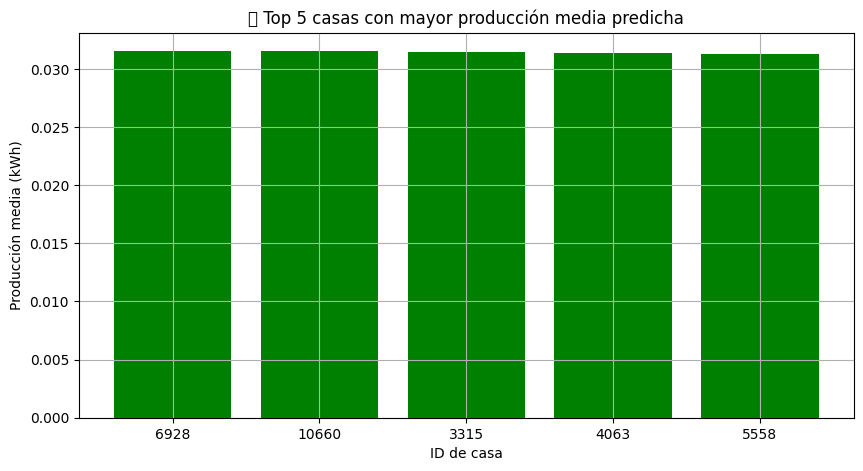

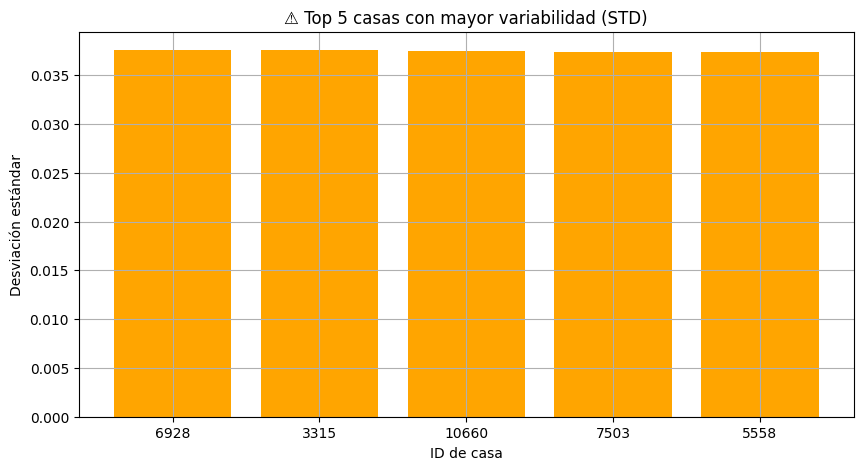

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


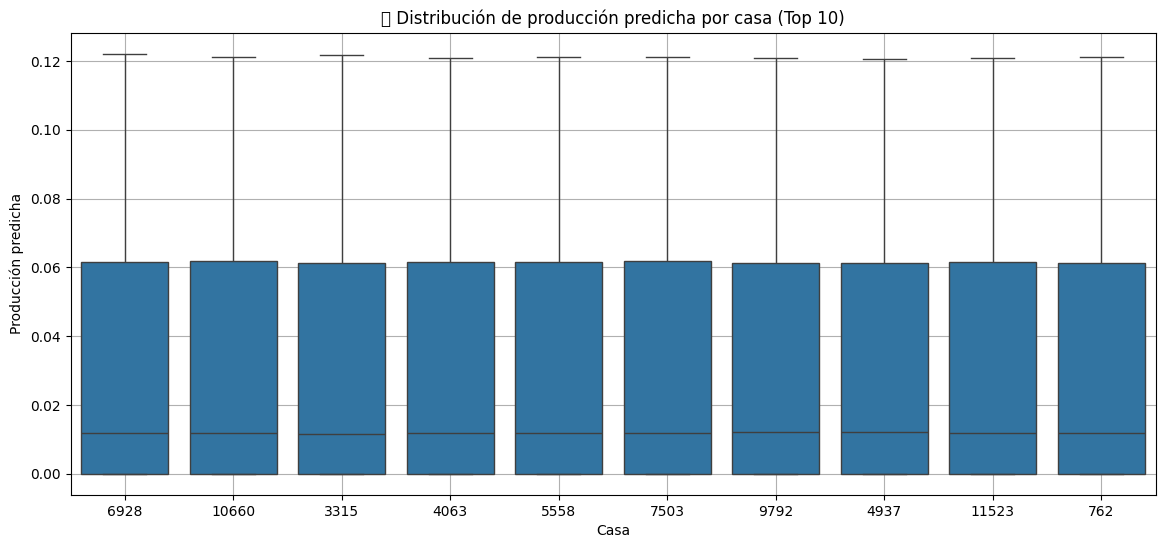

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


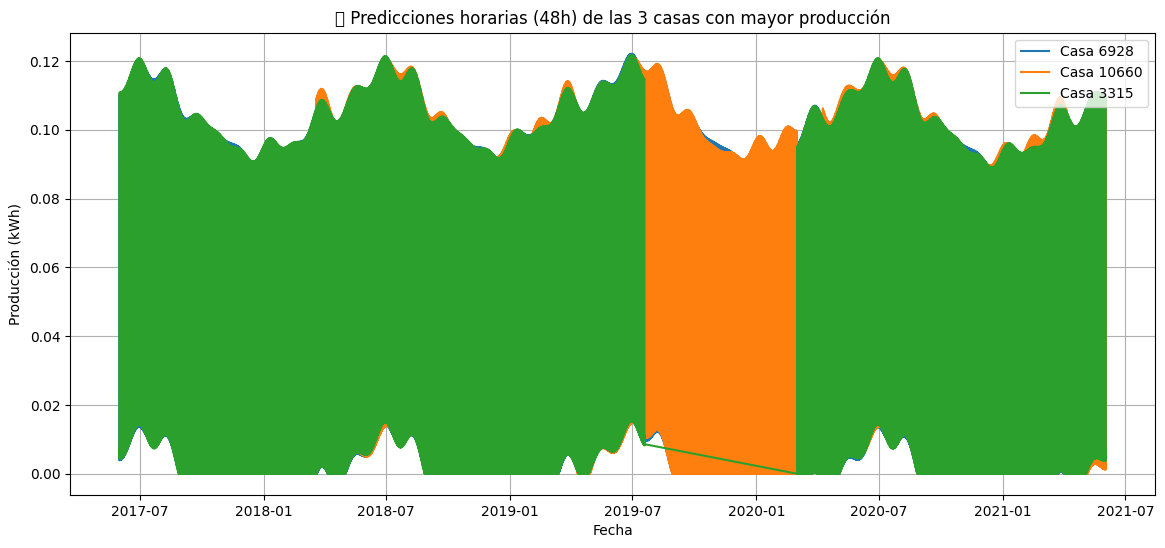

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Asegúrate de tener df_analisis ya cargado (con columnas: id_casa, produccion_media, variabilidad)

# 1. TOP 5 CASAS CON MAYOR PRODUCCIÓN MEDIA
top5 = df_analisis.sort_values("produccion_media", ascending=False).head(5)

plt.figure(figsize=(10, 5))
plt.bar(top5['id_casa'].astype(str), top5['produccion_media'], color='green')
plt.title("🔝 Top 5 casas con mayor producción media predicha")
plt.xlabel("ID de casa")
plt.ylabel("Producción media (kWh)")
plt.grid(True)
plt.show()

# 2. TOP 5 CASAS CON MÁS VARIABILIDAD (más irregulares)
top5_var = df_analisis.sort_values("variabilidad", ascending=False).head(5)

plt.figure(figsize=(10, 5))
plt.bar(top5_var['id_casa'].astype(str), top5_var['variabilidad'], color='orange')
plt.title("⚠️ Top 5 casas con mayor variabilidad (STD)")
plt.xlabel("ID de casa")
plt.ylabel("Desviación estándar")
plt.grid(True)
plt.show()

# 3. BOXPLOT de todas las predicciones (solo para casas seleccionadas)
# Tomamos una muestra aleatoria de 10 casas
muestra_ids = df_analisis.sort_values("produccion_media", ascending=False).head(10)['id_casa']

# Extraer predicciones de esas casas
data = []
for casa_id in muestra_ids:
    forecast = resultados_por_casa[casa_id]['forecast']
    for yhat in forecast['yhat']:
        data.append({'Casa': str(casa_id), 'Producción predicha': yhat})

df_plot = pd.DataFrame(data)

plt.figure(figsize=(14, 6))
sns.boxplot(x='Casa', y='Producción predicha', data=df_plot)
plt.title("📦 Distribución de producción predicha por casa (Top 10)")
plt.grid(True)
plt.show()

# 4. CURVAS DE PREDICCIÓN DE LAS MEJORES 3 CASAS
mejores_3_ids = df_analisis.sort_values("produccion_media", ascending=False).head(3)['id_casa']

plt.figure(figsize=(14, 6))
for casa_id in mejores_3_ids:
    forecast = resultados_por_casa[casa_id]['forecast']
    plt.plot(forecast['ds'], forecast['yhat'], label=f"Casa {casa_id}")

plt.title("📈 Predicciones horarias (48h) de las 3 casas con mayor producción")
plt.xlabel("Fecha")
plt.ylabel("Producción (kWh)")
plt.legend()
plt.grid(True)
plt.show()
